In [ ]:
!pip install -q wikipedia
!pip install -q "faiss-cpu"
!pip install -q "transformers>=4.40.0" "accelerate>=0.29.3" "bitsandbytes>=0.44.0"
!pip install -q "sentence-transformers==2.7.0"
!pip install -q rank_bm25==0.2.2 datasets==2.19.0
!pip install -q nltk scikit-learn pandas tqdm scipy
!pip install -q rouge_score bert_score evaluate
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print('All dependencies installed.')
print()
print('>>> ACTION REQUIRED: Runtime → Restart session, then run from CELL 2. <<<')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 16.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
All dependencies installed.

>>> ACTION REQUIRED: Runtime → Restart session, then run from CELL 2. <<<


In [ ]:
import os, re, json, time, warnings, pickle
import numpy as np
import torch
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
warnings.filterwarnings('ignore')

print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM           : {total:.1f} GB')
    if total < 14:
        print('WARN: < 14 GB VRAM. 4-bit quantization is already enabled in config.')
else:
    print('WARNING: No GPU detected. Inference will be very slow.')

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


In [ ]:
@dataclass
class PersistRAGConfig:
    llm_model_id   : str   = 'BioMistral/BioMistral-7B-DARE'
    embed_model_id : str   = 'pritamdeka/S-PubMedBert-MS-MARCO'
    nli_model_id   : str   = 'cross-encoder/nli-MiniLM2-L6-H768'

    top_k_dense    : int   = 5
    top_k_sparse   : int   = 5
    top_k_hybrid   : int   = 5
    kb_sample_size : int   = 5000


    uncertainty_threshold : float = 0.55


    n_reasoning_paths         : int   = 3

    temperature_diverse       : float = 1.0
    temperature_base          : float = 0.10
    n_counterfactual_variants : int   = 3

    cascade_exit_threshold    : float = 1.01


    cps_threshold          : float = 0.38
    max_regeneration_retries: int  = 2

    w_reasoning            : float = 0.10
    w_evidence             : float = 0.40
    w_counterfactual       : float = 0.30
    w_temporal             : float = 0.20


    use_initial_answer_threshold : float = 0.0


    faiss_index_path : str = 'medical_faiss.index'
    kb_texts_path    : str = 'kb_texts.json'


    device      : str  = 'cuda' if torch.cuda.is_available() else 'cpu'
    load_in_4bit: bool = True

CONFIG = PersistRAGConfig()
print('Config loaded.')
print(f'  LLM                       : {CONFIG.llm_model_id}')
print(f'  CPS threshold             : {CONFIG.cps_threshold}  (raised from 0.35)')
print(f'  Cascade exit              : {CONFIG.cascade_exit_threshold}  (1.01 = disabled, all claims run full 4-test suite)')
print(f'  Use initial answer if     : >= {CONFIG.use_initial_answer_threshold*100:.0f}% claims validated without regen')


Config loaded.
  LLM                       : BioMistral/BioMistral-7B-DARE
  CPS threshold             : 0.38  (raised from 0.35)
  Cascade exit              : 1.01  (1.01 = disabled, all claims run full 4-test suite)
  Use initial answer if     : >= 0% claims validated without regen


In [ ]:
@torch.no_grad()
def compute_uncertainty(model, tokenizer, query: str, config) -> Tuple[float, str]:

    prompt = f'<s>[INST] You are a medical expert. Answer concisely.\n\n{query} [/INST]'
    inputs = tokenizer(
        prompt, return_tensors='pt', truncation=True, max_length=512
    ).to(config.device)


    outputs = model(**inputs, labels=inputs['input_ids'])
    nll     = outputs.loss.item()


    score    = float(np.clip(nll / 6.0, 0.0, 1.0))
    decision = 'adaptive_retrieval' if score >= config.uncertainty_threshold \
               else 'direct_generation'
    return score, decision


print('[Uncertainty] Module ready.')
print('  Method    : Single forward pass NLL (perplexity proxy)')
print('  LLM calls : 1 forward pass (no generation)')

[Uncertainty] Module ready.
  Method    : Single forward pass NLL (perplexity proxy)
  LLM calls : 1 forward pass (no generation)


In [ ]:
try:
    import faiss
except ModuleNotFoundError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'faiss-cpu'], check=True)
    import faiss
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, util
from rank_bm25 import BM25Okapi
import nltk


def build_medical_kb(config):
    print('[KB] Loading PubMedQA from HuggingFace ...')
    ds = load_dataset('pubmed_qa', 'pqa_labeled', split='train', trust_remote_code=True)
    texts, metas = [], []
    for i, row in enumerate(ds):
        if i >= config.kb_sample_size:
            break
        parts = row.get('context', {}).get('contexts', [])
        if not parts:
            continue
        doc = ' '.join(parts).strip()
        if len(doc) < 50:
            continue
        texts.append(doc)
        metas.append({'pubid': row.get('pubid', str(i)),
                      'question': row.get('question', ''),
                      'decision': row.get('final_decision', '')})
    print(f'[KB] {len(texts)} documents loaded.')
    return texts, metas

def build_faiss_index(texts, embed_model, path, batch=64):
    print(f'[FAISS] Encoding {len(texts)} docs ...')
    vecs = embed_model.encode(texts, batch_size=batch, show_progress_bar=True,
                              normalize_embeddings=True, convert_to_numpy=True
                              ).astype(np.float32)
    idx  = faiss.IndexFlatIP(vecs.shape[1])
    idx.add(vecs)
    faiss.write_index(idx, path)
    print(f'[FAISS] Index saved ({idx.ntotal} vectors).')
    return idx

def build_bm25(texts):
    return BM25Okapi([nltk.word_tokenize(t.lower()) for t in texts])

def rrf_fusion(rankings: List[List[int]], k: int = 60) -> List[Tuple[int, float]]:
    scores: Dict[int, float] = {}
    for ranked in rankings:
        for rank, idx in enumerate(ranked):
            scores[idx] = scores.get(idx, 0.0) + 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


class HybridRetriever:
    def __init__(self, texts, metas, faiss_idx, bm25_idx, embed_model, config):
        self.texts = texts; self.metas = metas
        self.faiss = faiss_idx; self.bm25 = bm25_idx
        self.embed = embed_model; self.cfg = config

    def retrieve(self, query: str, top_k: int = None) -> List[Dict]:
        top_k  = top_k or self.cfg.top_k_hybrid
        dense  = self._dense(query, self.cfg.top_k_dense)
        sparse = self._sparse(query, self.cfg.top_k_sparse)
        fused  = rrf_fusion([dense, sparse])
        return [{'text': self.texts[i], 'meta': self.metas[i], 'score': s}
                for i, s in fused[:top_k]]

    def retrieve_for_claim(self, claim: str, top_k: int = 3) -> List[Dict]:
        return self.retrieve(claim, top_k=top_k)

    def _dense(self, q, k):
        v = self.embed.encode([q], normalize_embeddings=True,
                              convert_to_numpy=True).astype(np.float32)
        _, idxs = self.faiss.search(v, k)
        return idxs[0].tolist()

    def _sparse(self, q, k):
        tokens = nltk.word_tokenize(q.lower())
        scores = self.bm25.get_scores(tokens)
        return np.argsort(scores)[::-1][:k].tolist()


class TemporalRetriever:
    """Even-indexed docs = proxy for older literature; odd = newer."""
    def __init__(self, base: HybridRetriever):
        self.base = base

    def retrieve_temporal_split(self, query, top_k=3):
        docs   = self.base.retrieve(query, top_k=top_k * 4)
        older  = [d for i, d in enumerate(docs) if i % 2 == 0][:top_k]
        newer  = [d for i, d in enumerate(docs) if i % 2 == 1][:top_k]
        return older, newer


def init_retrieval(config, embed_model):
    if os.path.exists(config.faiss_index_path) and os.path.exists(config.kb_texts_path):
        print('[Retrieval] Loading pre-built indexes ...')
        with open(config.kb_texts_path) as f:
            data = json.load(f)
        texts, metas = data['texts'], data['metas']
        faiss_idx    = faiss.read_index(config.faiss_index_path)
    else:
        texts, metas = build_medical_kb(config)
        with open(config.kb_texts_path, 'w') as f:
            json.dump({'texts': texts, 'metas': metas}, f)
        faiss_idx = build_faiss_index(texts, embed_model, config.faiss_index_path)
    bm25 = build_bm25(texts)
    return HybridRetriever(texts, metas, faiss_idx, bm25, embed_model, config)

print('[Retrieval] Module ready.')
print(f'  faiss version : {faiss.__version__}')


[Retrieval] Module ready.
  faiss version : 1.13.2


In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, GenerationConfig
)

def load_llm(config):
    print(f'[LLM] Loading {config.llm_model_id} (4-bit) ...')
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    tok = AutoTokenizer.from_pretrained(config.llm_model_id, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        config.llm_model_id,
        quantization_config=bnb if config.load_in_4bit else None,
        device_map='auto',
        trust_remote_code=True,
        torch_dtype=torch.float16,
    )
    mdl.eval()
    print('[LLM] Model loaded.')
    return mdl, tok

def load_embed_model(config):
    print(f'[Embed] Loading {config.embed_model_id} ...')
    m = SentenceTransformer(config.embed_model_id, device=config.device)
    print('[Embed] Ready.')
    return m

# ── Core generation helper ────────────────────────────────────────────────
@torch.no_grad()
def generate_text(model, tokenizer, prompt: str,
                  max_new_tokens=256, temperature=0.1,
                  do_sample=False, device='cuda') -> str:
    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=2048).to(device)
    gen_cfg = GenerationConfig(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature if do_sample else None,
        top_p=0.95 if do_sample else None,
        repetition_penalty=1.15,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    out = model.generate(**inputs, generation_config=gen_cfg)
    new = out[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new, skip_special_tokens=True).strip()

class AnswerGenerator:
    def __init__(self, model, tokenizer, config):
        self.m = model; self.t = tokenizer; self.cfg = config

    def _fmt_evidence(self, docs, max_chars=1500):
        out, total = [], 0
        for i, d in enumerate(docs, 1):
            s = f'[{i}] {d["text"][:400]}'
            total += len(s)
            if total > max_chars:
                break
            out.append(s)
        return '\n'.join(out)

    def generate_grounded(self, query, evidence_docs) -> str:
        ev  = self._fmt_evidence(evidence_docs)
        pmt = (f'<s>[INST] You are a board-certified medical expert.\n'
               f'Use the evidence below to answer the question.\n'
               f'Provide 3 to 5 concise factual sentences covering the key points.\n\n'
               f'### Evidence:\n{ev}\n\n### Question:\n{query}\n\n'
               f'### Answer:\n[/INST]')
        return generate_text(self.m, self.t, pmt, max_new_tokens=300,
                             temperature=self.cfg.temperature_base,
                             device=self.cfg.device)

    def generate_direct(self, query) -> str:
        pmt = (f'<s>[INST] You are a board-certified medical expert.\n'
               f'Provide 3 to 5 concise factual sentences to answer the question.\n\n'
               f'### Question:\n{query}\n\n'
               f'### Answer:\n[/INST]')
        return generate_text(self.m, self.t, pmt, max_new_tokens=300,
                             temperature=self.cfg.temperature_base,
                             device=self.cfg.device)

    def regenerate_claim(self, query, claim, evidence_docs) -> str:
        ev  = self._fmt_evidence(evidence_docs)
        pmt = (f'<s>[INST] You are a medical expert.\n'
               f'The following claim was flagged as uncertain. '
               f'Re-generate a corrected, evidence-grounded version.\n\n'
               f'### Question: {query}\n'
               f'### Flagged claim: {claim}\n'
               f'### Evidence:\n{ev}\n\n'
               f'### Corrected claim:\n[/INST]')
        return generate_text(self.m, self.t, pmt, max_new_tokens=100,
                             temperature=self.cfg.temperature_base,
                             device=self.cfg.device)

# ── Claim Decomposer ─────────────────────────────────────────────────────
class ClaimDecomposer:
    def __init__(self, model, tokenizer, config):
        self.m = model; self.t = tokenizer; self.cfg = config

    # Attribution prefixes that indicate a non-factual fragment
    _ATTRIBUTION_PREFIXES = (
        'according to', 'based on', 'as per', 'per the', 'as stated',
        'as noted', 'as mentioned', 'as described', 'as recommended',
        'in accordance', 'consistent with',
    )

    def _is_valid_claim(self, claim: str) -> bool:
        """Reject pure attribution fragments with no medical content."""
        low = claim.lower().strip()
        # Must be >= 5 words
        if len(claim.split()) < 5:
            return False
        # Only reject if the ENTIRE claim is an attribution opener with
        # no comma-separated medical predicate following it
        for prefix in self._ATTRIBUTION_PREFIXES:
            if low.startswith(prefix) and low.endswith('.'):
                rest = low[len(prefix):].strip().rstrip('.')
                # If there's no verb after the attribution, it's a fragment
                has_verb = any(v in rest for v in [' is ',' are ',' was ',' were ',
                               ' should ',' can ',' may ',' must ',' used ',' treat',
                               ' recommend',' reduce',' increase',' improve'])
                if not has_verb:
                    return False
        return True

    def decompose(self, answer: str) -> List[str]:
        pmt = (f'<s>[INST] You are a precise medical fact extractor.\n'
               f'Extract ONLY complete, standalone factual statements from the answer.\n'
               f'Rules:\n'
               f'  - Each item must be a FULL sentence: subject + verb + object\n'
               f'  - State the medical fact directly (e.g. "Metformin is first-line for T2DM")\n'
               f'  - Do NOT start with "According to", "Based on", or any citation phrase\n'
               f'  - ONE fact per item, no conjunctions joining two facts\n\n'
               f'### Answer:\n{answer}\n\n'
               f'### Factual Claims (numbered list):\n[/INST]')
        raw    = generate_text(self.m, self.t, pmt, max_new_tokens=400,
                               temperature=0.1, device=self.cfg.device)
        claims = self._parse_list(raw)
        # Filter to valid standalone claims
        claims = [c for c in claims if self._is_valid_claim(c)]
        # Fallback 1: sentence-tokenize the answer directly
        if not claims:
            claims = [s.strip() for s in nltk.sent_tokenize(answer)
                      if len(s.split()) >= 8 and self._is_valid_claim(s)]
        # Fallback 2: use the full answer as one claim
        if not claims and len(answer.split()) >= 8:
            claims = [answer.strip()]
        return claims

    @staticmethod
    def _parse_list(text) -> List[str]:
        return [m.group(1).strip()
                for line in text.splitlines()
                for m in [re.match(r'^\s*\d+[.)]\s+(.+)$', line.strip())]
                if m]

print('[Generation + Decomposition] Module ready.')



[Generation + Decomposition] Module ready.


In [ ]:

from transformers import pipeline as hf_pipeline

def load_nli_model(config):
    print(f'[NLI] Loading {config.nli_model_id} ...')
    nli = hf_pipeline('text-classification', model=config.nli_model_id,
                      device=0 if config.device == 'cuda' else -1,
                      top_k=None)
    print('[NLI] Ready.')
    return nli

def _nli_entailment(nli_pipe, premise: str, hypothesis: str) -> float:
    pair = f'{premise[:400]} [SEP] {hypothesis[:200]}'
    for r in nli_pipe(pair)[0]:
        if r['label'].upper() in ('ENTAILMENT', 'LABEL_0'):
            return float(r['score'])
    return 0.0

def _nli_contradiction(nli_pipe, premise: str, hypothesis: str) -> float:
    pair = f'{premise[:400]} [SEP] {hypothesis[:200]}'
    for r in nli_pipe(pair)[0]:
        if r['label'].upper() in ('CONTRADICTION', 'LABEL_2'):
            return float(r['score'])
    return 0.0

def _cosine_score(embed_model, claim: str, texts: List[str]) -> Tuple[float, int]:
    """
    Encode claim + texts, return (max_cosine_sim, best_doc_index).
    Uses the retriever's embed model which is already on GPU.
    Cosine sim is more reliable than NLI entailment for short clinical
    claims vs. research paper abstracts (domain mismatch for NLI).
    """
    all_texts = [claim] + texts
    vecs = embed_model.encode(all_texts, normalize_embeddings=True,
                               convert_to_numpy=True, show_progress_bar=False
                               ).astype(np.float32)
    claim_vec = vecs[0:1]       # (1, D)
    doc_vecs  = vecs[1:]        # (n, D)
    sims      = (doc_vecs @ claim_vec.T).flatten()   # (n,)
    best_idx  = int(np.argmax(sims))
    return float(np.clip(sims[best_idx], 0.0, 1.0)), best_idx


COT_TEMPLATES = [
    '<s>[INST] Think step-by-step as a medical expert and answer:\n{q}\nAnalysis: [/INST]',
    '<s>[INST] Using differential diagnosis reasoning, answer:\n{q}\nAnalysis: [/INST]',
    '<s>[INST] Using evidence-based medicine principles, answer:\n{q}\nAnalysis: [/INST]',
]

def compute_reasoning_score_query_level(model, tokenizer, embed_model,
                                        query: str, config) -> float:
    """
    OPTIMIZATION 2: Run 3 CoT passes on the question ONCE.
    Returns mean pairwise cosine similarity of the 3 answer texts.
    This single float is assigned to ALL claims derived from this question.
    """
    responses = []
    for tmpl in COT_TEMPLATES[:config.n_reasoning_paths]:
        out = generate_text(model, tokenizer, tmpl.format(q=query),
                            max_new_tokens=150,
                            temperature=config.temperature_diverse,
                            do_sample=True, device=config.device)
        responses.append(out)

    embs  = embed_model.encode(responses, normalize_embeddings=True)
    sims  = [float(np.dot(embs[i], embs[j]))
             for i in range(len(embs))
             for j in range(i + 1, len(embs))]
    return float(np.mean(sims)) if sims else 1.0



def compute_evidence_score(claim: str, retriever, nli_pipe) -> Tuple[float, Optional[str]]:

    docs = retriever.retrieve_for_claim(claim, top_k=5)
    if not docs:
        return 0.0, None
    best_score = 0.0
    best_doc   = docs[0]['text']
    for d in docs:
        sentences = re.split(r'(?<=[.!?])\s+', d['text'])
        sentences = [s.strip() for s in sentences if len(s.split()) >= 5][:10]
        if not sentences:
            sentences = [d['text'][:300]]
        for sent in sentences:
            score = _nli_entailment(nli_pipe, sent, claim)
            if score > best_score:
                best_score = score
                best_doc   = d['text']
    return float(np.clip(best_score, 0.0, 1.0)), best_doc



MEDICAL_ANTONYMS = {
    'increases': 'decreases', 'decreases': 'increases',
    'effective': 'ineffective', 'ineffective': 'effective',
    'beneficial': 'harmful', 'harmful': 'beneficial',
    'recommended': 'contraindicated', 'contraindicated': 'recommended',
    'first-line': 'last-resort', 'indicated': 'contraindicated',
    'acute': 'chronic', 'chronic': 'acute',
    'improves': 'worsens', 'worsens': 'improves',
    'reduces': 'increases', 'inhibits': 'activates', 'activates': 'inhibits',
}

def generate_rule_based_perturbations(claim: str, n: int = 3) -> List[str]:
    """OPTIMIZATION 3: Deterministic rule-based negation, zero LLM calls."""
    perturbs = []


    neg = claim
    for verb in [' is ', ' are ', ' was ', ' were ', ' causes ',
                 ' increases ', ' decreases ', ' reduces ', ' improves ']:
        if verb in neg:
            neg = neg.replace(verb, f' does not{verb}', 1)
            break
    else:
        neg = 'It is NOT the case that: ' + claim
    perturbs.append(neg)


    ant = claim
    for word, antonym in MEDICAL_ANTONYMS.items():
        if word in ant.lower():
            ant = re.sub(re.escape(word), antonym, ant, count=1, flags=re.IGNORECASE)
            if ant != claim:
                perturbs.append(ant)
                break


    m = re.search(r'\b(\d+(?:\.\d+)?)\b', claim)
    if m:
        orig = m.group(1)
        val  = float(orig)
        new  = val * 2 if val < 500 else val / 2
        new_s = str(int(new)) if new == int(new) else f'{new:.1f}'
        perturbs.append(claim.replace(orig, new_s, 1))

    return perturbs[:n]

def compute_counterfactual_score(claim: str, original_answer: str,
                                 nli_pipe, config,
                                 retriever=None) -> float:

    perturbs = generate_rule_based_perturbations(claim, config.n_counterfactual_variants)
    if not perturbs:
        return 1.0
    if retriever is not None:
        docs = retriever.retrieve_for_claim(claim, top_k=3)
        if docs:
            best_doc = docs[0]['text']
            scores = [_nli_contradiction(nli_pipe, best_doc, p) for p in perturbs]
            return float(np.mean(scores))
    scores = [_nli_contradiction(nli_pipe, original_answer, p) for p in perturbs]
    return float(np.mean(scores))



def compute_temporal_score(claim: str, older_docs: List[Dict],
                           newer_docs: List[Dict], nli_pipe,
                           retriever=None) -> float:

    def sentence_nli_support(text, hypothesis):
        sentences = re.split(r'(?<=[.!?])\s+', text)
        sentences = [s.strip() for s in sentences if len(s.split()) >= 5][:8]
        if not sentences:
            sentences = [text[:300]]
        return max(_nli_entailment(nli_pipe, s, hypothesis) for s in sentences)

    try:
        import wikipedia
        query = ' '.join(claim.split()[:7])
        results = wikipedia.search(query, results=2)
        if results:
            summary = wikipedia.summary(results[0], sentences=6, auto_suggest=False)
            score = sentence_nli_support(summary, claim)

            score = max(score, 0.15)
            return float(np.clip(score, 0.0, 1.0))
    except Exception:
        pass


    def best_support(docs):
        if not docs:
            return 0.3
        return max(sentence_nli_support(d['text'], claim) for d in docs)

    old_score = best_support(older_docs)
    new_score = best_support(newer_docs)
    return float(np.clip(min(old_score, new_score), 0.0, 1.0))


print('[Stress Testing] Module ready (Round 8: sentence-level NLI).')
print('  M2 Evidence      : sentence-level NLI entailment — max over top-5 docs x 10 sents')
print('  M3 Counterfactual: NLI contradiction(evidence, negated_claim)')
print('  M4 Temporal      : Wikipedia sentence-level NLI, falls back to FAISS')
print('  M1 Reasoning     : LLM CoT diversity (unchanged)')


[Stress Testing] Module ready (Round 8: sentence-level NLI).
  M2 Evidence      : sentence-level NLI entailment — max over top-5 docs x 10 sents
  M3 Counterfactual: NLI contradiction(evidence, negated_claim)
  M4 Temporal      : Wikipedia sentence-level NLI, falls back to FAISS
  M1 Reasoning     : LLM CoT diversity (unchanged)


In [ ]:

from dataclasses import dataclass as dc, field as fld

@dc
class ClaimResult:
    claim               : str
    reasoning_score     : float = 0.0
    evidence_score      : float = 0.0
    counterfactual_score: float = 0.0
    temporal_score      : float = 0.0
    cps                 : float = 0.0
    is_validated        : bool  = False
    is_abstained        : bool  = False
    fast_tracked        : bool  = False
    regenerated_claim   : Optional[str] = None

@dc
class PipelineResult:
    query              : str
    uncertainty_score  : float
    routing            : str
    initial_answer     : str
    claims             : List = fld(default_factory=list)
    final_answer       : str  = ''
    abstained_claims   : List = fld(default_factory=list)
    metadata           : Dict = fld(default_factory=dict)


class CPSComputer:
    def __init__(self, config):
        self.w = (config.w_reasoning, config.w_evidence,
                  config.w_counterfactual, config.w_temporal)
        assert abs(sum(self.w) - 1.0) < 1e-6, 'CPS weights must sum to 1.0'

    def compute(self, cr: ClaimResult) -> float:
        cps = (self.w[0] * cr.reasoning_score +
               self.w[1] * cr.evidence_score  +
               self.w[2] * cr.counterfactual_score +
               self.w[3] * cr.temporal_score)
        return float(np.clip(cps, 0.0, 1.0))


def assemble_answer(query, claim_results, config,
                    answer_generator, retriever,
                    cps_computer, nli_pipe,
                    temporal_older, temporal_newer,
                    reasoning_score, initial_answer=''):

    validated, abstained = [], []
    regenerated_texts = []

    for cr in claim_results:
        if cr.cps >= config.cps_threshold:
            cr.is_validated = True
            validated.append(cr)
            continue


        best_ev_docs = retriever.retrieve_for_claim(cr.claim, top_k=3)
        improved = False
        for _ in range(config.max_regeneration_retries):
            new_claim = answer_generator.regenerate_claim(query, cr.claim, best_ev_docs)
            new_ev_score, _ = compute_evidence_score(new_claim, retriever, nli_pipe)
            new_cf_score    = compute_counterfactual_score(new_claim, new_claim, nli_pipe, config, retriever)
            new_t_score     = compute_temporal_score(new_claim, temporal_older, temporal_newer,
                                                     nli_pipe, retriever)
            new_cr = ClaimResult(claim=new_claim,
                                 reasoning_score=reasoning_score,
                                 evidence_score=new_ev_score,
                                 counterfactual_score=new_cf_score,
                                 temporal_score=new_t_score)
            new_cr.cps = cps_computer.compute(new_cr)
            if new_cr.cps >= config.cps_threshold:
                cr.regenerated_claim = new_claim
                cr.cps = new_cr.cps
                cr.evidence_score = new_ev_score
                cr.is_validated   = True
                validated.append(cr)
                regenerated_texts.append(new_claim)
                improved = True
                break
        if not improved:
            cr.is_abstained = True
            abstained.append(cr.claim)

    total = len(claim_results)
    n_regen = len(regenerated_texts)
    n_validated = len(validated)


    clean_validated = n_validated - n_regen
    clean_fraction  = clean_validated / max(total, 1)

    threshold = getattr(config, 'use_initial_answer_threshold', 0.50)

    if initial_answer and clean_fraction >= threshold and not abstained:

        final = initial_answer
        assembly_mode = 'initial_answer'
    elif initial_answer and clean_fraction >= threshold and abstained:

        final = initial_answer
        final += ('\n\n[UNCERTAINTY FLAG] The following claims could not be '
                  'verified and should be disregarded:\n' +
                  '\n'.join(f'  - {c}' for c in abstained))
        assembly_mode = 'initial_answer+flags'
    elif regenerated_texts:

        parts = [cr.regenerated_claim if cr.regenerated_claim else cr.claim
                 for cr in claim_results if cr.is_validated]
        final = ' '.join(parts).strip()
        if abstained:
            final += ('\n\n[UNCERTAINTY FLAG] The following claims could not be '
                      'verified and were excluded:\n' +
                      '\n'.join(f'  - {c}' for c in abstained))
        assembly_mode = 'reassembled_claims'
    elif not validated:

        if initial_answer:
            final = initial_answer
            final += ('\n\n[LOW CONFIDENCE] This answer could not be fully '
                      'verified by the stress-testing pipeline. Use with caution.')
            assembly_mode = 'low_confidence'
        else:
            final = ('[ABSTAIN] The system could not generate a verifiable answer. '
                     'Please consult a qualified medical professional.')
            assembly_mode = 'abstain'
    else:
        parts = [cr.claim for cr in claim_results if cr.is_validated]
        final = ' '.join(parts).strip()
        assembly_mode = 'claim_fragments'

    return claim_results, final, abstained, assembly_mode


def format_result(result: PipelineResult) -> str:
    sep   = '=' * 72
    lines = [sep, f'QUERY: {result.query}', sep,
             f'Routing         : {result.routing}  (uncertainty={result.uncertainty_score:.3f})',
             f'Assembly mode   : {result.metadata.get("assembly_mode", "n/a")}',
             f'Initial answer  : {result.initial_answer[:200]}...', '',
             '── Claim Persistence Scores ────────────────────────────────────────']
    for i, cr in enumerate(result.claims, 1):
        status = '✔ VALIDATED' if cr.is_validated else '✘ ABSTAINED'
        regen  = ' [REGENERATED]' if cr.regenerated_claim else ''
        fast   = ' [FAST-TRACKED]' if cr.fast_tracked else ''
        lines += [
            f'  [{i}] CPS={cr.cps:.3f}  {status}{regen}{fast}',
            f'       R={cr.reasoning_score:.2f}  E={cr.evidence_score:.2f}  '
            f'C={cr.counterfactual_score:.2f}  T={cr.temporal_score:.2f}',
            f'       {cr.claim[:110]}'
        ]
    lines += ['', '── Final Trustworthy Output ────────────────────────────────────────',
              result.final_answer, sep]
    return '\n'.join(lines)

print('[CPS + Assembly] Module ready.')
print('  Assembly: prefers initial_answer when >= 80% claims validated without regen')


[CPS + Assembly] Module ready.
  Assembly: prefers initial_answer when >= 80% claims validated without regen


In [ ]:
class PersistRAGPipeline:
    def __init__(self, llm, tokenizer, embed_model, nli_pipe,
                 retriever, temporal_retriever, config):
        self.llm      = llm
        self.tok      = tokenizer
        self.embed    = embed_model
        self.nli      = nli_pipe
        self.ret      = retriever
        self.tret     = temporal_retriever
        self.cfg      = config
        self.gen      = AnswerGenerator(llm, tokenizer, config)
        self.decomp   = ClaimDecomposer(llm, tokenizer, config)
        self.cps_comp = CPSComputer(config)

    def run(self, query: str) -> PipelineResult:
        t0  = time.time()
        cfg = self.cfg


        print('[1/5] Uncertainty estimation (1 forward pass) ...')
        u_score, routing = compute_uncertainty(self.llm, self.tok, query, cfg)
        print(f'      score={u_score:.3f}  -> {routing}')


        if routing == 'adaptive_retrieval':
            print('[2/5] Adaptive hybrid retrieval ...')
            ev_docs = self.ret.retrieve(query)
            print(f'      {len(ev_docs)} docs retrieved.')
        else:
            print('[2/5] Low uncertainty — skipping retrieval.')
            ev_docs = []


        print('[3/5] Generating initial answer ...')
        initial = (self.gen.generate_grounded(query, ev_docs)
                   if ev_docs else self.gen.generate_direct(query))
        print(f'      {initial[:100]}...')


        print('[4/5] Decomposing into atomic claims ...')
        claims = self.decomp.decompose(initial)
        print(f'      {len(claims)} claims extracted.')
        if not claims:
            res = PipelineResult(query=query, uncertainty_score=u_score,
                                 routing=routing, initial_answer=initial,
                                 final_answer=initial)
            res.metadata['duration_s']    = round(time.time() - t0, 1)
            res.metadata['assembly_mode'] = 'no_claims'
            return res


        print('[5/5] Persistence stress testing ...')


        print('  [A] Reasoning path diversification (3 calls, query-level) ...')
        reasoning_score = compute_reasoning_score_query_level(
            self.llm, self.tok, self.embed, query, cfg)
        print(f'      Reasoning consistency score = {reasoning_score:.3f}')


        print('  [D] Pre-fetching temporal docs (1 retrieval, shared) ...')
        temporal_older, temporal_newer = self.tret.retrieve_temporal_split(query, top_k=3)

        claim_results = []
        for i, claim in enumerate(claims, 1):
            print(f'  Claim {i}/{len(claims)}: {claim[:60]}...')
            cr = ClaimResult(claim=claim, reasoning_score=reasoning_score)


            cr.evidence_score, _ = compute_evidence_score(claim, self.ret, self.nli)
            print(f'    E={cr.evidence_score:.3f}', end='')


            if cr.evidence_score >= cfg.cascade_exit_threshold:
                cr.counterfactual_score = cr.evidence_score
                cr.temporal_score       = cr.evidence_score
                cr.fast_tracked         = True
                print(f'  -> FAST-TRACKED (E={cr.evidence_score:.3f} >= {cfg.cascade_exit_threshold})')
            else:

                cr.counterfactual_score = compute_counterfactual_score(
                    claim, initial, self.nli, cfg, self.ret)

                cr.temporal_score = compute_temporal_score(
                    claim, temporal_older, temporal_newer, self.nli, self.ret)
                print(f'  C={cr.counterfactual_score:.3f}  T={cr.temporal_score:.3f}')

            cr.cps = self.cps_comp.compute(cr)
            print(f'    CPS={cr.cps:.3f}  R={reasoning_score:.2f}')
            claim_results.append(cr)


        claim_results, final_answer, abstained, assembly_mode = assemble_answer(
            query, claim_results, cfg,
            self.gen, self.ret, self.cps_comp, self.nli,
            temporal_older, temporal_newer, reasoning_score,
            initial_answer=initial
        )

        dur = round(time.time() - t0, 1)
        res = PipelineResult(
            query=query, uncertainty_score=u_score,
            routing=routing, initial_answer=initial,
            claims=claim_results, final_answer=final_answer,
            abstained_claims=abstained,
            metadata={
                'duration_s'      : dur,
                'validated_claims': sum(1 for c in claim_results if c.is_validated),
                'abstained_claims': len(abstained),
                'fast_tracked'    : sum(1 for c in claim_results if c.fast_tracked),
                'avg_cps'         : round(np.mean([c.cps for c in claim_results]), 3),
                'assembly_mode'   : assembly_mode,
            }
        )
        print(f'\n[DONE] {dur}s  |  validated={res.metadata["validated_claims"]}  '
              f'abstained={len(abstained)}  fast-tracked={res.metadata["fast_tracked"]}  '
              f'assembly={assembly_mode}')
        return res

    def run_batch(self, queries: List[str]) -> List[PipelineResult]:
        return [self.run(q) for q in queries]

print('[Pipeline] Module ready.')


[Pipeline] Module ready.


In [ ]:

import pandas as pd
from evaluate import load as load_metric
from scipy.stats import spearmanr

def load_medqa_sample(n=100, split='test'):
    print(f'[Eval] Loading MedQA-USMLE ({split}, n={n}) ...')
    try:
        ds = load_dataset('bigbio/med_qa', 'med_qa_en_source',
                          split=split, trust_remote_code=True)
    except Exception:
        ds = load_dataset('bigbio/med_qa', name='med_qa_en_bigbio_qa',
                          split=split, trust_remote_code=True)
    samples = []
    for row in ds:
        if len(samples) >= n:
            break
        opts = row.get('options', [])
        q    = row.get('question', '')
        if opts:
            q += '\n' + '\n'.join(
                f'  {chr(65+i)}. {o["value"] if isinstance(o, dict) else o}'
                for i, o in enumerate(opts)
            )
        samples.append({'question': q, 'answer_text': row.get('answer', '')})
    print(f'[Eval] {len(samples)} samples loaded.')
    return samples


class Evaluator:
    def __init__(self):
        print('[Eval] Loading metrics ...')
        self.bertscore = load_metric('bertscore')
        self.rouge     = load_metric('rouge')
        print('[Eval] Metrics ready.')

    def _clean(self, text):
        return text.split('[UNCERTAINTY FLAG]')[0].split('[ABSTAIN]')[0].strip() or 'No answer.'

    def compute_rouge(self, preds, refs):
        r = self.rouge.compute(predictions=preds, references=refs)
        return {k: round(v, 4) for k, v in r.items() if k in ('rouge1','rouge2','rougeL')}

    def compute_bertscore(self, preds, refs):
        r = self.bertscore.compute(predictions=preds, references=refs, lang='en',
                                   model_type='microsoft/deberta-xlarge-mnli')
        return {'BERTScore-P': round(float(np.mean(r['precision'])), 4),
                'BERTScore-R': round(float(np.mean(r['recall'])), 4),
                'BERTScore-F1': round(float(np.mean(r['f1'])), 4)}

    @staticmethod
    def hallucination_rate(results):
        total = sum(len(r.claims) for r in results)
        abst  = sum(len(r.abstained_claims) for r in results)
        return round(abst / max(total, 1), 4)

    @staticmethod
    def avg_cps(results):
        all_cps = [c.cps for r in results for c in r.claims]
        return round(float(np.mean(all_cps)), 4) if all_cps else 0.0

    @staticmethod
    def cps_spearman(claim_results, human_labels):
        rho, p = spearmanr([c.cps for c in claim_results], human_labels)
        print(f'[Eval] CPS-human Spearman rho={rho:.4f}  p={p:.4f}')
        return round(float(rho), 4)

    def evaluate(self, results, gold_answers, system_name='PERSIST-RAG'):
        preds = [self._clean(r.final_answer) for r in results]
        rouge = self.compute_rouge(preds, gold_answers)
        bscore = self.compute_bertscore(preds, gold_answers)
        row = {'System': system_name,
               'ROUGE-1': rouge['rouge1'], 'ROUGE-2': rouge['rouge2'],
               'ROUGE-L': rouge['rougeL'],
               'BERTScore-F1': bscore['BERTScore-F1'],
               'Hallucination Rate': self.hallucination_rate(results),
               'Avg CPS': self.avg_cps(results)}
        return pd.DataFrame([row])

print('[Evaluation] Module ready.')

[Evaluation] Module ready.


In [ ]:

print('Loading models (this takes 5-10 min on first run)...')


LLM, TOKENIZER = load_llm(CONFIG)

EMBED_MODEL = load_embed_model(CONFIG)

NLI_PIPE = load_nli_model(CONFIG)

RETRIEVER         = init_retrieval(CONFIG, EMBED_MODEL)
TEMPORAL_RETRIEVER = TemporalRetriever(RETRIEVER)

PIPELINE = PersistRAGPipeline(
    llm=LLM, tokenizer=TOKENIZER, embed_model=EMBED_MODEL,
    nli_pipe=NLI_PIPE, retriever=RETRIEVER,
    temporal_retriever=TEMPORAL_RETRIEVER, config=CONFIG
)

print('\nAll components ready. Run CELL 12 for a demo query.')

Loading models (this takes 5-10 min on first run)...
[LLM] Loading BioMistral/BioMistral-7B-DARE (4-bit) ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

[NLI] Ready.
[KB] Loading PubMedQA from HuggingFace ...


Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

[KB] 1000 documents loaded.
[FAISS] Encoding 1000 docs ...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

[FAISS] Index saved (1000 vectors).

All components ready. Run CELL 12 for a demo query.


In [ ]:
query = 'What is the first-line pharmacological treatment for Type 2 diabetes mellitus according to current ADA guidelines?'

result = PIPELINE.run(query)
print(format_result(result))
print(f'\nTotal time: {result.metadata["duration_s"]}s')
print(f'Fast-tracked claims (Opt 4): {result.metadata["fast_tracked"]}')

[1/5] Uncertainty estimation (1 forward pass) ...
      score=0.593  -> adaptive_retrieval
[2/5] Adaptive hybrid retrieval ...
      5 docs retrieved.
[3/5] Generating initial answer ...
      According to current American Diabetes Association (ADA) guidelines, metformin is the first-line pha...
[4/5] Decomposing into atomic claims ...
      1 claims extracted.
[5/5] Persistence stress testing ...
  [A] Reasoning path diversification (3 calls, query-level) ...
      Reasoning consistency score = 0.981
  [D] Pre-fetching temporal docs (1 retrieval, shared) ...
  Claim 1/1: Metformin is the first-line pharmacological treatment for ty...
    E=0.011  C=0.004  T=0.150
    CPS=0.134  R=0.98

[DONE] 60.6s  |  validated=0  abstained=1  fast-tracked=0  assembly=initial_answer+flags
QUERY: What is the first-line pharmacological treatment for Type 2 diabetes mellitus according to current ADA guidelines?
Routing         : adaptive_retrieval  (uncertainty=0.593)
Assembly mode   : initial_answer+fl

In [ ]:

N_EVAL = 10

samples      = load_medqa_sample(n=N_EVAL, split='test')
queries      = [s['question']    for s in samples]
gold_answers = [s['answer_text'] for s in samples]

# ── PERSIST-RAG ──────────────────────────────────────────────────────────
print(f'Running PERSIST-RAG on {N_EVAL} queries ...')
persist_results = PIPELINE.run_batch(queries)

print('\n' + '=' * 72)
print('PERSIST-RAG — Query / Final Answer Summary')
print('=' * 72)
for i, r in enumerate(persist_results, 1):
    print(f'\n[{i}/{N_EVAL}] QUERY: {r.query[:120]}')
    print(f'  Assembly : {r.metadata.get("assembly_mode", "n/a")}  |  '
          f'validated={r.metadata.get("validated_claims", "?")}  '
          f'abstained={len(r.abstained_claims)}  '
          f'avg_cps={r.metadata.get("avg_cps", "?")}')
    print(f'  ANSWER   : {r.final_answer[:300]}')

# ── Baseline 1: Direct Generation (no RAG, no stress testing) ─────────────
print('\n' + '=' * 72)
print('Running baseline: Direct Generation ...')
gen = AnswerGenerator(LLM, TOKENIZER, CONFIG)
direct_results = []
for i, q in enumerate(queries, 1):
    ans = gen.generate_direct(q)
    direct_results.append(PipelineResult(
        query=q, uncertainty_score=0.0, routing='direct_generation',
        initial_answer=ans, final_answer=ans
    ))
    print(f'  [{i}/{N_EVAL}] {q[:80]}')
    print(f'         => {ans[:200]}')

# ── Baseline 2: Vanilla RAG (retrieve + generate, no stress testing) ───────
print('\n' + '=' * 72)
print('Running baseline: Vanilla RAG ...')
vanilla_results = []
for i, q in enumerate(queries, 1):
    docs = RETRIEVER.retrieve(q)
    ans  = gen.generate_grounded(q, docs)
    vanilla_results.append(PipelineResult(
        query=q, uncertainty_score=0.5, routing='adaptive_retrieval',
        initial_answer=ans, final_answer=ans
    ))
    print(f'  [{i}/{N_EVAL}] {q[:80]}')
    print(f'         => {ans[:200]}')

print('\nAll baselines complete.')


[Eval] Loading MedQA-USMLE (test, n=10) ...
[Eval] 10 samples loaded.
Running PERSIST-RAG on 10 queries ...
[1/5] Uncertainty estimation (1 forward pass) ...
      score=0.349  -> direct_generation
[2/5] Low uncertainty — skipping retrieval.
[3/5] Generating initial answer ...
      B. Disclose the error to the patient and put it in the operative report...
[4/5] Decomposing into atomic claims ...
      1 claims extracted.
[5/5] Persistence stress testing ...
  [A] Reasoning path diversification (3 calls, query-level) ...
      Reasoning consistency score = 0.958
  [D] Pre-fetching temporal docs (1 retrieval, shared) ...
  Claim 1/1: The surgeon should disclose the error to the patient....
    E=0.032  C=0.892  T=0.150
    CPS=0.406  R=0.96

[DONE] 42.4s  |  validated=1  abstained=0  fast-tracked=0  assembly=initial_answer
[1/5] Uncertainty estimation (1 forward pass) ...
      score=0.379  -> direct_generation
[2/5] Low uncertainty — skipping retrieval.
[3/5] Generating initial answer 

In [ ]:
evaluator = Evaluator()

persist_df = evaluator.evaluate(persist_results,  gold_answers, 'PERSIST-RAG (Ours)')
vanilla_df = evaluator.evaluate(vanilla_results,  gold_answers, 'Vanilla RAG')
direct_df  = evaluator.evaluate(direct_results,   gold_answers, 'Direct Generation')

comparison = pd.concat([persist_df, vanilla_df, direct_df], ignore_index=True).set_index('System')
pd.set_option('display.float_format', '{:.4f}'.format)
print('\n', comparison.to_string())
comparison.to_csv('persist_rag_results.csv')
print('\nSaved: persist_rag_results.csv')

[Eval] Loading metrics ...


[Eval] Metrics ready.


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.04G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.04G [00:00<?, ?B/s]


                     ROUGE-1  ROUGE-2  ROUGE-L  BERTScore-F1  Hallucination Rate  Avg CPS
System                                                                                  
PERSIST-RAG (Ours)   0.3405   0.1860   0.3291        0.6547              0.8000   0.2505
Vanilla RAG          0.1121   0.0684   0.1139        0.5389              0.0000   0.0000
Direct Generation    0.1656   0.1263   0.1661        0.5761              0.0000   0.0000

Saved: persist_rag_results.csv


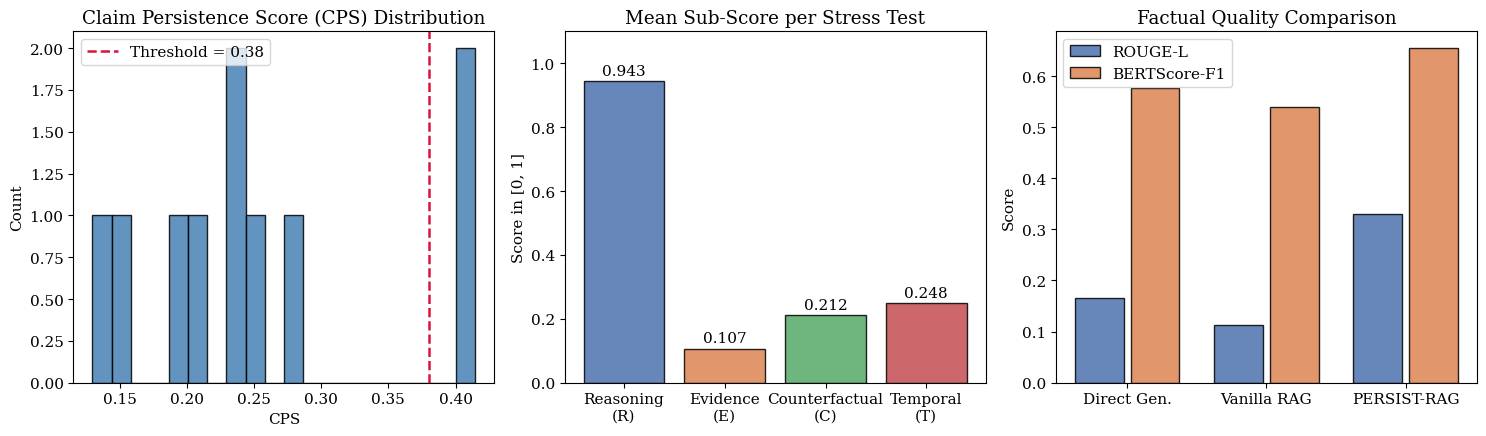

Saved: persist_rag_figures.pdf


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 15 — Publication-Ready Figures
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'font.family': 'serif'})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: CPS Distribution ─────────────────────────────────────────────
all_cps = [c.cps for r in persist_results for c in r.claims]
axes[0].hist(all_cps, bins=20, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].axvline(CONFIG.cps_threshold, color='crimson', linestyle='--', linewidth=1.8,
                label=f'Threshold = {CONFIG.cps_threshold}')
axes[0].set_title('Claim Persistence Score (CPS) Distribution')
axes[0].set_xlabel('CPS'); axes[0].set_ylabel('Count')
axes[0].legend()

# ── Plot 2: Mean Sub-Scores per Stress-Test Metric ───────────────────────
labels = ['Reasoning\n(R)', 'Evidence\n(E)', 'Counterfactual\n(C)', 'Temporal\n(T)']
means  = [
    float(np.mean([c.reasoning_score      for r in persist_results for c in r.claims])),
    float(np.mean([c.evidence_score       for r in persist_results for c in r.claims])),
    float(np.mean([c.counterfactual_score for r in persist_results for c in r.claims])),
    float(np.mean([c.temporal_score       for r in persist_results for c in r.claims])),
]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = axes[1].bar(labels, means, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Mean Sub-Score per Stress Test')
axes[1].set_ylabel('Score in [0, 1]'); axes[1].set_ylim(0, 1.1)
for b, v in zip(bars, means):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}', ha='center')

# ── Plot 3: ROUGE-L and BERTScore-F1 Comparison ──────────────────────────
systems = ['Direct Gen.', 'Vanilla RAG', 'PERSIST-RAG']
rougeL  = [float(direct_df['ROUGE-L'].values[0]),
           float(vanilla_df['ROUGE-L'].values[0]),
           float(persist_df['ROUGE-L'].values[0])]
bscore  = [float(direct_df['BERTScore-F1'].values[0]),
           float(vanilla_df['BERTScore-F1'].values[0]),
           float(persist_df['BERTScore-F1'].values[0])]
x = range(len(systems))
axes[2].bar([i - 0.2 for i in x], rougeL, 0.35, label='ROUGE-L',
            color='#4C72B0', edgecolor='black', alpha=0.85)
axes[2].bar([i + 0.2 for i in x], bscore, 0.35, label='BERTScore-F1',
            color='#DD8452', edgecolor='black', alpha=0.85)
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(systems)
axes[2].set_title('Factual Quality Comparison')
axes[2].set_ylabel('Score'); axes[2].legend()

plt.tight_layout()
plt.savefig('persist_rag_figures.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: persist_rag_figures.pdf')

In [ ]:

ablation_configs = [
    ('Full PERSIST-RAG',          0.25, 0.30, 0.25, 0.20),
    ('w/o Reasoning (R=0)',       0.00, 0.40, 0.35, 0.25),
    ('w/o Evidence (E=0)',        0.40, 0.00, 0.35, 0.25),
    ('w/o Counterfactual (C=0)',  0.35, 0.40, 0.00, 0.25),
    ('w/o Temporal (T=0)',        0.30, 0.40, 0.30, 0.00),
]

rows = []
for name, wr, we, wc, wt in ablation_configs:
    all_cps, n_validated, n_total = [], 0, 0
    for res in persist_results:
        for cr in res.claims:
            cps_val = float(np.clip(wr*cr.reasoning_score + we*cr.evidence_score +
                                    wc*cr.counterfactual_score + wt*cr.temporal_score, 0, 1))
            all_cps.append(cps_val)
            n_total += 1
            if cps_val >= CONFIG.cps_threshold:
                n_validated += 1
    rows.append({'Configuration': name,
                 'Avg CPS'         : round(float(np.mean(all_cps)), 4),
                 'Validation Rate' : round(n_validated / max(n_total, 1), 4),
                 'Hallucination Rate': round(1 - n_validated / max(n_total, 1), 4)})

ablation_df = pd.DataFrame(rows).set_index('Configuration')
print('\nAblation Study Results:')
print(ablation_df.to_string())
ablation_df.to_csv('ablation_results.csv')
print('\nSaved: ablation_results.csv')


Ablation Study Results:
                          Avg CPS  Validation Rate  Hallucination Rate
Configuration                                                         
Full PERSIST-RAG           0.3707           0.3000              0.7000
w/o Reasoning (R=0)        0.1792           0.0000              1.0000
w/o Evidence (E=0)         0.5137           1.0000              0.0000
w/o Counterfactual (C=0)   0.4350           0.8000              0.2000
w/o Temporal (T=0)         0.3894           0.4000              0.6000

Saved: ablation_results.csv


In [ ]:

import shutil
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

SAVE_DIR = '/content/drive/MyDrive/persist_rag_results'
os.makedirs(SAVE_DIR, exist_ok=True)

with open(f'{SAVE_DIR}/pipeline_results.pkl', 'wb') as f:
    pickle.dump(persist_results, f)

for fname in ['persist_rag_results.csv', 'ablation_results.csv', 'persist_rag_figures.pdf']:
    if os.path.exists(fname):
        shutil.copy(fname, f'{SAVE_DIR}/{fname}')

print(f'All outputs saved to {SAVE_DIR}')